Deep Reinforcement Learning
Assignment 1
Part 1 (MAB - Multi-Armed Bandit)
Group Number - 163

In [8]:
# Installing Required Libraries 
import pandas as pd
import numpy as np
import random 
import matplotlib.pyplot as plt

TASK 1: DATASET DESIGN & ENVIRONMENT SETUP

In [9]:
# Setting seeds for reproducibility - ensures we get the same random numbers
G = 163
random.seed(G)
np.random.seed(G)

In [10]:
# Calculate number of medicines (K = (G % 3) + 5)

K = (G % 3) + 5
print(f"Group Number(G): {G}")
print(f"Number of Medicines(K): {K}")

Group Number(G): 163
Number of Medicines(K): 6


In [11]:
# Calculate hidden success probabilities for each medicine (Pi = 0.4 + ((G + i) % 6) * 0.07)

hidden_probs = []
for i in range(K):
    pi = 0.4 + ((G+i)%6) * 0.07
    hidden_probs.append(pi)

print("Hidden Success Probabilities")
for i,p in enumerate(hidden_probs, start = 1):
    print(f"Medicine: {i}: {p:.2f}")

print(f"\nBest Medicine: Medicine {np.argmax(hidden_probs)+1} "
        f"(Probability = {max(hidden_probs):.2f})")

Hidden Success Probabilities
Medicine: 1: 0.47
Medicine: 2: 0.54
Medicine: 3: 0.61
Medicine: 4: 0.68
Medicine: 5: 0.75
Medicine: 6: 0.40

Best Medicine: Medicine 5 (Probability = 0.75)


In [12]:
# Generating Dataset 
# patient_id: 0 to 999
# severity_score: (patient_id % 5) + 1

num_patients = 1000

# Creating base dataset using pre-known columns
df_base = pd.DataFrame({
    'patient_id': range(num_patients),
    'serverity_score': [(pid % 5)+1 for pid in range(num_patients)]
})

# Adding placeholder columns that algorithms will fill dynamically
df_base['assigned_medicine'] = None
df_base['clinical_outcome']  = None
df_base['utility_score']     = None

# Displaying Dataset Sample
print("Base patient dataset:")
print(df_base.sample(10).to_string(index=False))
print(f"\nTotal patients: {len(df_base)}")
print(f"Severity score range: {df_base['serverity_score'].min()} to "
      f"{df_base['serverity_score'].max()}")


Base patient dataset:
 patient_id  serverity_score assigned_medicine clinical_outcome utility_score
        613                4              None             None          None
        585                1              None             None          None
        799                5              None             None          None
        822                3              None             None          None
        774                5              None             None          None
        697                3              None             None          None
        512                3              None             None          None
        333                4              None             None          None
        297                3              None             None          None
        133                4              None             None          None

Total patients: 1000
Severity score range: 1 to 5


Yugansh Jindal

Priyanshi Singh

Niti Jain

TASK 3: UCB STRATEGY
Initial Exploration Phase : First 6 patients (1 trial per medicine)
UCB Exploitation Phase    : Remaining 994 patients

Sample of 10 rows of result:
 patient_id  serverity_score assigned_medicine clinical_outcome utility_score
        947                3                 5                0           0.0
        362                3                 3                1           0.7
        635                1                 4                0           0.0
        954                5                 3                1           0.5
        456                2                 2                1           0.8
        129                5                 2                1           0.5
        441                2                 1                0           0.0
        339                5                 3                1           0.5
        873                4                 5                0           0.0
        429                5                 4    

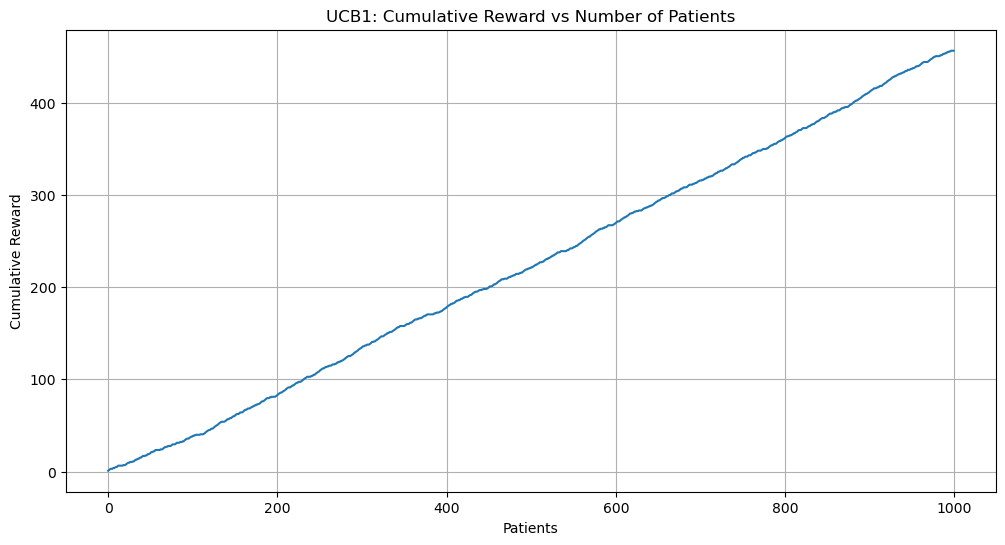

In [ ]:
#UCB (Upper Confidence Bound) Algorithm
def run_ucb_strategy(df_base, K, G):
    """
    Implements the UCB (Upper Confidence Bound) Strategy.

    Parameters:
        df_base : base dataframe with patient_id and severity_score
        K       : total number of medicines
        G       : group number (used for seed)

    Returns:
        df_result          : dataframe with all columns filled
        cumulative_rewards : list of cumulative reward at each step
    """

    # Import required library
    import math

    # Reset seeds for reproducibility
    random.seed(G)
    np.random.seed(G)

    # Making a copy of base data
    df_result = df_base.copy()

    # Total number of patients
    num_patients = 1000

    # Hidden probabilities for medicines
    P = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]

    # Initializing tracking variables

    # Number of times each medicine is selected
    medicine_counts = np.zeros(K)

    # Total rewards collected by each medicine
    medicine_rewards = np.zeros(K)

    # Tracking cumulative reward over time
    cumulative_rewards = []
    total_reward = 0

    print("TASK 3: UCB STRATEGY")
    print(f"Initial Exploration Phase : First {K} patients "
          f"(1 trial per medicine)")
    print(f"UCB Exploitation Phase    : Remaining "
          f"{num_patients - K} patients")

    # Looping through all patients
    for patient in range(num_patients):

        # Get this patient's severity score
        severity = df_result.loc[patient, 'serverity_score']

        # ==========================================
        # PHASE 1: INITIAL EXPLORATION
        # Try each medicine exactly once
        # ==========================================

        if patient < K:

            # Assign each medicine once
            med = patient

        # ==========================================
        # PHASE 2: UCB SELECTION
        # Select medicine with highest UCB value
        # ==========================================

        else:

            # Store UCB values
            ucb_values = []

            # Calculate UCB for every medicine
            for i in range(K):

                # Average reward of medicine i
                avg_reward = (
                    medicine_rewards[i] / medicine_counts[i]
                )

                # Confidence interval term
                confidence = math.sqrt(
                    (2 * math.log(patient + 1))
                    / medicine_counts[i]
                )

                # UCB Formula
                ucb = avg_reward + confidence

                # Store UCB value
                ucb_values.append(ucb)

            # Select medicine with maximum UCB value
            med = np.argmax(ucb_values)

        # ==========================================
        # SIMULATE CLINICAL OUTCOME
        # ==========================================

        # Simulate patient recovery
        # 1 = recovered, 0 = not recovered
        outcome = np.random.binomial(1, P[med])

        # ==========================================
        # CALCULATE UTILITY SCORE
        # ==========================================

        reward = outcome * (1 - severity / 10)

        # ==========================================
        # UPDATE TRACKING VARIABLES
        # ==========================================

        # Increase selection count
        medicine_counts[med] += 1

        # Add reward earned
        medicine_rewards[med] += reward

        # Update cumulative reward
        total_reward += reward
        cumulative_rewards.append(total_reward)

        # ==========================================
        # STORE RESULTS IN DATAFRAME
        # ==========================================

        df_result.loc[patient, 'assigned_medicine'] = med
        df_result.loc[patient, 'clinical_outcome'] = outcome
        df_result.loc[patient, 'utility_score'] = reward

    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print("\nSample of 10 rows of result:")
    print(df_result.sample(10).to_string(index=False))

    print("\nFINAL STATISTICS:")

    # Print medicine usage statistics
    print("\nMedicine Usage:")

    for i in range(K):

        estimated_reward = (
            medicine_rewards[i] / medicine_counts[i]
        )

        print(f"  Medicine {i}: Used "
              f"{int(medicine_counts[i]):4d} times | "
              f"Estimated Reward: {estimated_reward:.4f} | "
              f"True Prob: {P[i]:.2f}")

    # Print total rewards
    print(f"\nTotal Cumulative Reward : "
          f"{total_reward:.2f}")

    print(f"Average Reward/Patient  : "
          f"{total_reward/num_patients:.4f}")

    # Best medicine identified by UCB
    best_medicine = np.argmax(
        medicine_rewards / medicine_counts
    )

    print(f"\nBest Medicine Identified by UCB: "
          f"Medicine {best_medicine}")

    print(f"True Best Medicine: Medicine "
          f"{np.argmax(P)} "
          f"(prob={max(P):.2f})")

    # Return dataframe and rewards
    return df_result, cumulative_rewards


# Run the UCB Strategy
df_ucb, rewards_ucb = run_ucb_strategy(
    df_base, K, G
)

# ==========================================
# PLOT CUMULATIVE REWARD
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(rewards_ucb)

plt.title("UCB1: Cumulative Reward vs Number of Patients")

plt.xlabel("Patients")

plt.ylabel("Cumulative Reward")

plt.grid(True)

plt.show()